# Visualize the Education's Impact Spatially

In [1]:
import os, sys

sys.path.append(os.path.abspath("."))

In [2]:
os.chdir(CURRENT_ADDR := os.path.abspath(".."))

In [3]:
CURRENT_ADDR

'/mnt/d/OneDrive/MLD01_Article'

## Impact Package

In [7]:
import geopandas as gpd
import math
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import os, sys
import pandas as pd

from glob import glob
from matplotlib import cm


In [8]:
import LoadDataFromDisk

In [9]:
import importlib
importlib.reload(LoadDataFromDisk)

<module 'LoadDataFromDisk' from '/mnt/d/OneDrive/MLD01_Article/MLD01e_Code/LoadDataFromDisk.py'>

## Function

In [10]:
def load_spatial_data() -> gpd.GeoDataFrame:
    """
    Load and combine Nepal EcoBelt and Province spatial data.

    This function:
    1. Loads the EcoBelt shapefile (3-class version: Mountain, Hill, Terai).
    2. Loads the Province shapefile.
    3. Converts both to the same CRS (EPSG:4326, WGS84).
    4. Computes the spatial intersection between EcoBelts and Provinces.

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame containing intersected polygons 
                          with both EcoBelt and Province attributes.
    """
    # --- Load EcoBelt shapefile ---
    gdf_eco = gpd.read_file('PrivateData/SpatialMaps/nepal_ecobelt_data/3_class_shape/Ecobelts_3Class.shp')
    gdf_eco = gdf_eco.to_crs(epsg=4326)
    
    # --- Load Province shapefile ---
    gdf_nepal = gpd.read_file('PrivateData/SpatialMaps/02_PROVINCE/PROVINCE.shp')
    gdf_nepal = gdf_nepal[['geometry', 'Province']].to_crs(epsg=4326)
    
    # --- Intersection ---
    try:
        gdf_intersect = gpd.overlay(gdf_eco, gdf_nepal, how='intersection')
    except Exception as e:
        raise RuntimeError(f"❌ Failed to overlay EcoBelt and Province shapefiles: {e}")

    # --- Optional cleanup ---
    gdf_intersect = gdf_intersect.rename(columns={'EcoBelt': 'Eco_Belt'}) if 'EcoBelt' in gdf_intersect.columns else gdf_intersect
    
    print(f"✅ Loaded spatial data with {len(gdf_intersect)} intersected polygons.")
    return gdf_intersect

In [11]:
def build_province_diff_df(
    probs_dictionary: dict[str, pd.DataFrame],
    input_name_list: list[str],
    province_column: pd.Series,
    ecobelt_column: pd.Series
) -> pd.DataFrame:
    """
    Build a DataFrame of mean probability differences (factual - counterfactual)
    across all Province × EcoBelt combinations for each variable in input_name_list.
    
    Args:
        probs_dictionary (dict): Dictionary with factual and counterfactual DataFrames.
        input_name_list (list): List of input variable names (without 'counter' prefix).
        province_column (pd.Series): Province label for each observation.
        ecobelt_column (pd.Series): EcoBelt label for each observation.
    
    Returns:
        pd.DataFrame: A DataFrame where rows are Province–EcoBelt combinations,
                      and columns are input names.
    """
    province_list = sorted(province_column.unique())
    ecobelt_list = sorted(ecobelt_column.unique())
    
    # Create a combined index of Province × EcoBelt
    index_pairs = [(prov, eco) for prov in province_list for eco in ecobelt_list]
    
    # Prepare an empty DataFrame
    df_diff = pd.DataFrame(index=pd.MultiIndex.from_tuples(index_pairs, names=["Province", "EcoBelt"]),
                           columns=input_name_list, dtype=float)
    
    # Convert to arrays once for speed
    prov_arr = province_column.to_numpy()
    eco_arr = ecobelt_column.to_numpy()

    # Main computation
    for input_name in input_name_list:
        factual_df = probs_dictionary[input_name].copy()
        counterfactual_df = probs_dictionary[f'counter{input_name}'].copy()
        
        factual_df['Province'] = prov_arr
        factual_df['EcoBelt'] = eco_arr
        counterfactual_df['Province'] = prov_arr
        counterfactual_df['EcoBelt'] = eco_arr

        for prov, eco in index_pairs:
            mask_factual = (factual_df['Province'] == prov) & (factual_df['EcoBelt'] == eco)
            mask_counter = (counterfactual_df['Province'] == prov) & (counterfactual_df['EcoBelt'] == eco)
            
            if mask_factual.sum() > 0 and mask_counter.sum() > 0:
                diff = counterfactual_df.loc[mask_factual, 'mean'].mean() - factual_df.loc[mask_counter, 'mean'].mean()
            else:
                diff = float('nan')
            
            df_diff.loc[(prov, eco), input_name] = diff

    return df_diff

In [38]:
def plot_spatial_differences(map_diff_df: gpd.GeoDataFrame, save_address: str):
    """
    Plot spatial differences for each variable in the GeoDataFrame.

    Args:
        map_diff_df (gpd.GeoDataFrame): GeoDataFrame with spatial data and differences.
        save_address (str): File path to save the resulting figure.
    """
    # Define per-column vmin/vmax
    vmaxs = [0.060, 0.030, 0.020, 0.010, 0.030, 0.030]
    vmins = [0.030, 0.005, 0, 0, 0, 0]

    # Prepare subplots (2 rows × 3 columns)
    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    axes = axes.flatten()

    # Colormap
    cmap = plt.cm.RdYlBu_r
    sub_figure_code = list("abcdefghijklmnopqrstuvwxyz")

    titles = [
        "(a) Heard about Climate Change Dummy", "(b) Climate Change Awareness Dummy",
        "(c) Soil and Water Conservation Measures in Past Dummy", "(d) Risk Reduction Measurement in Past Dummy",
        "(e) Road Improvement in Past Dummy", "(f) Community Participation in Past Dummy"
        
    ]

    # Plot each variable
    for idx, col in enumerate(map_diff_df.columns[:6]):
        ax = axes[idx]

        # Plot GeoDataFrame without legend
        map_diff_df.plot(
            column=col,
            cmap=cmap,
            edgecolor='black',
            linewidth=0.4,
            vmin=vmins[idx],
            vmax=vmaxs[idx],
            alpha=0.8,
            legend=False,
            ax=ax
        )
        for i, row in map_diff_df.iterrows():
            geom = row.geometry
            if geom is not None and not geom.is_empty:
                cx, cy = geom.centroid.x, geom.centroid.y
                ax.text(cx, cy, f"{i[0]}\n{i[1]}", fontsize=7, ha='center', va='center').set_path_effects([
                    path_effects.Stroke(linewidth=2.5, foreground='white'),
                    path_effects.Normal()
                ])

        # Create a colorbar manually with matching height
        sm = mpl.cm.ScalarMappable(
            norm=mpl.colors.Normalize(vmin=vmins[idx], vmax=vmaxs[idx]),
            cmap=cmap
        )
        sm._A = []  # required for ScalarMappable
        cbar = fig.colorbar(sm, ax=ax, fraction=0.030, pad=0.02)  # adjust height
        cbar.ax.tick_params(labelsize=8)

        # Style
        ax.set_title(titles[idx], fontsize=10, loc = 'left')

        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.grid(True, linestyle='-', alpha=0.4)
        ax.axis('on')

    # Remove empty subplot(s)
    for ax in axes[len(map_diff_df.columns[:6]):]:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_address, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Violin plots saved to: {save_address}")

## Run

In [13]:
if __name__ == '__main__':
    pass

In [14]:
os.makedirs(MLD01e1_RESULTS_ADDR := './MLD01e_Results/MLD01e1_Results', exist_ok=True)

In [15]:
probs_dictionary = LoadDataFromDisk.read_all_probs_df_from_parquet(MLD01e1_RESULTS_ADDR)

In [16]:
input_name_list = ['factual_knowledge_probs', 'factual_awareness_probs', 
                   'factual_action_probs_soilandwater', 'factual_action_probs_riskreduction', 
                   'factual_action_probs_roadimprovement', 'factual_action_probs_communityparticipation']

In [17]:
map_df = load_spatial_data()

✅ Loaded spatial data with 20 intersected polygons.


In [18]:
map_df.columns = ['EcoBelt', "Province", 'geometry']

In [19]:
map_df

,EcoBelt,Province,geometry
0,Hill,Koshi,"MULTIPOLYGON (((86.45833 27.60833, 86.48333 27..."
1,Hill,Madesh,"MULTIPOLYGON (((85.03333 27.35833, 85.025 27.3..."
2,Hill,Bagmati,"MULTIPOLYGON (((85 27.375, 85 27.36667, 85.033..."
3,Hill,Lumbini,"MULTIPOLYGON (((81.80833 28.26667, 81.78333 28..."
4,Hill,Karnali,"MULTIPOLYGON (((81.775 28.3, 81.79167 28.3, 81..."
5,Hill,Gandaki,"MULTIPOLYGON (((83.8 27.60833, 83.8 27.6, 83.7..."
6,Hill,Sudur Pashchim,"MULTIPOLYGON (((81.13333 28.81667, 81.13333 28..."
7,Mountain,Koshi,"MULTIPOLYGON (((87.91667 27.08333, 87.90833 27..."
8,Mountain,Bagmati,"MULTIPOLYGON (((85.975 27.56667, 85.98333 27.5..."
9,Mountain,Lumbini,"MULTIPOLYGON (((83.025 28.3248, 83.02512 28.32..."


In [20]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [21]:
province_name = df_all['Prov'].unique().tolist()

In [22]:
df_diff = build_province_diff_df(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    province_column=df_all['Prov'],
    ecobelt_column=df_all['EcoBelt']
)

In [23]:
# Fix inconsistent province name
map_df.loc[map_df['Province'] == 'Sudur Pashchim', 'Province'] = 'Sudurpashchim'

# Set multi-index with Province and EcoBelt
map_df = map_df.set_index(['Province', 'EcoBelt'])

In [24]:
map_diff_df = df_diff.merge(map_df, left_index=True, right_index=True)

In [25]:
map_diff_df = gpd.GeoDataFrame(map_diff_df, geometry='geometry')

In [26]:
map_diff_df.describe()

,factual_knowledge_probs,factual_awareness_probs,factual_action_probs_soilandwater,factual_action_probs_riskreduction,factual_action_probs_roadimprovement,factual_action_probs_communityparticipation
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.049595,0.014904,0.010192,0.005690,0.007835,0.009072
std,0.011755,0.008000,0.006314,0.003478,0.008619,0.009036
min,0.032301,0.006621,0.000396,0.001982,0.000232,-0.000741
25%,0.040219,0.009088,0.005679,0.002920,0.001706,0.003845
50%,0.049399,0.012548,0.009877,0.003683,0.003462,0.005865
75%,0.058490,0.015690,0.012325,0.009759,0.013728,0.009703
max,0.071010,0.033980,0.021023,0.010321,0.029982,0.030369


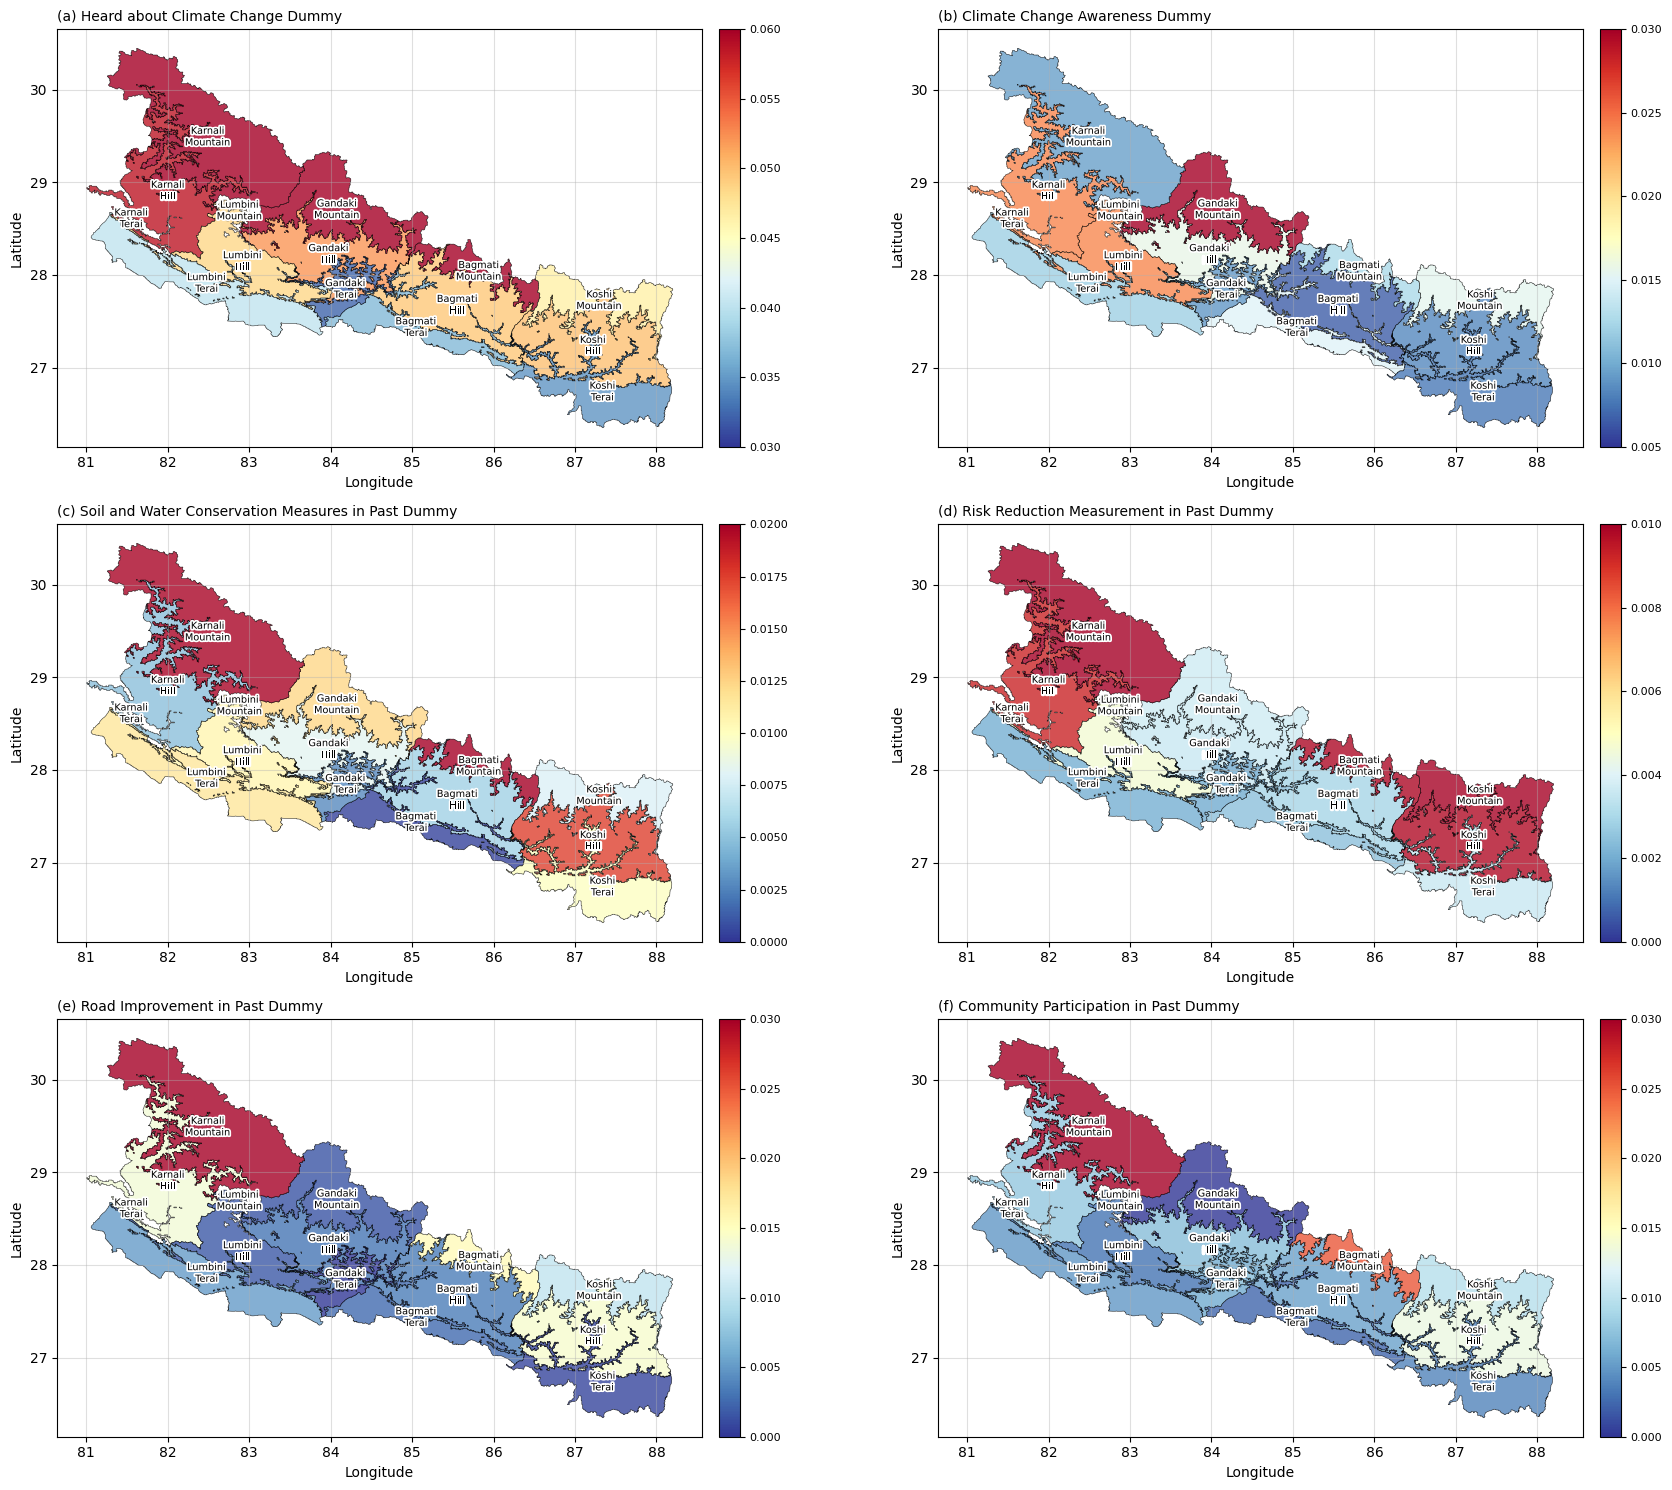

✅ Violin plots saved to: ./MLD01e_Figures/MLD01e1_SpatiallyVisualizeEducationResult_v1.jpg


In [39]:
plot_spatial_differences(
    map_diff_df=map_diff_df,
    save_address='./MLD01e_Figures/MLD01e1_SpatiallyVisualizeEducationResult_v1.jpg'
)